In [1]:


#@title Import the needed libraries
#@markdown Run this block to import the dependencies.
import pkg_resources
import os
from glob import glob
import cv2
import time
import matplotlib.pyplot as plt
%matplotlib inline
from openpiv_cpu.cpu_process import piv_cpu

from Scripts.SAM3Interface import SAM3Mask
import numpy as np

/tmp/ipykernel_5231/1348716818.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


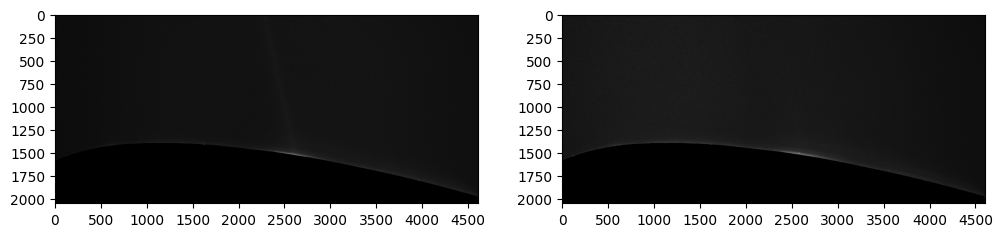

In [2]:
Name1="Frame_00000.tif" #Change name for PIV image used to generate mask
Name2="Frame_00001.tif" #Change name for PIV image used to generate mask
InputPath=os.path.join(os.getcwd(),"input")
GenPath1=os.path.join(os.getcwd(),"input",Name1)
GenPath2=os.path.join(os.getcwd(),"input",Name2)
OutPath=os.path.join(os.getcwd(), "Temp.png")

frame_a  = cv2.imread(GenPath1, cv2.IMREAD_ANYDEPTH)
frame_b  = cv2.imread(GenPath2, cv2.IMREAD_ANYDEPTH)

fig, axs = plt.subplots(1, 2, figsize=(12,10))
axs[0].imshow(frame_a, cmap=plt.cm.gray)
axs[1].imshow(frame_b, cmap=plt.cm.gray)

# Modify tick labels and ticks.
tick_step = 250
ht, wd = frame_a.shape
for ax in axs:
    ax.set_xticks(range(0, wd, 2 * tick_step))
    ax.set_yticks(range(0, ht, tick_step))

plt.show()

Is CUDA available: True
Current device: 0
Device name: NVIDIA GeForce RTX 3070 Laptop GPU
Processing images from: /home/leo/SAM3OpenPIV/SAM3-Masking-for-OpenPIV/input/Frame_00000.tif
Depth: 2052
Height: 4603
Width: 3
Detected
tensor([0.9453], device='cuda:0', dtype=torch.bfloat16)


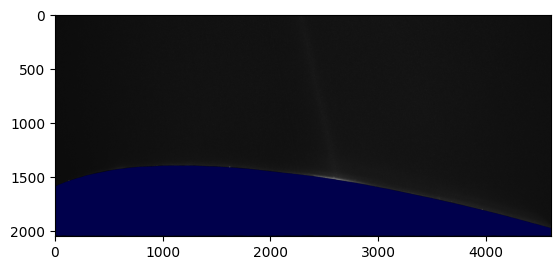

In [3]:
MaskOut=SAM3Mask(GenPath1)

Source = cv2.imread(GenPath1)

CroppedMask=MaskOut.astype(np.uint8) * 255
color_mask = cv2.cvtColor(CroppedMask, cv2.COLOR_GRAY2BGR)
color_mask[MaskOut] = [255, 0, 0] # Blue BGR

img = cv2.addWeighted(color_mask, 0.3, Source, 1, 0)

image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

In [5]:
#@title PIV settings
#@markdown The shape of the images is `(2052, 4603)`.
frame_shape = (2052, 4603) #@param {type:"raw"}
min_search_size = 16 #@param [16, 32, 64] {type:"raw"}
search_size_iters = (1, 2, 2,) #@param {type:"raw"}
mask = CroppedMask #@param {type:"raw"}


In [6]:


#@title Perform PIV processing
#@markdown Run this block to process the images.
# Initialize the process.
process = piv_cpu(frame_shape,
                  min_search_size=16,
                  search_size_iters=(1, 2, 2),
                  mask=CroppedMask,
                  median_tol=None,
                  s2n_tol=1.5)

# Get the field coordinates.
x, y = process.coords

# Invert the y axis.Conclusions
y = y[::-1]

# Process the images.
start_time = time.time()
u, v = process(frame_a, frame_b)
v = -v

# Printout the computation time.
process_time = time.time() - start_time
print('Computation time for {} image pair was {:.3f} s.'.format(1, process_time))

# Get the locations of the unreliable vectors.
loc = process.val_locations
_loc = ~loc



Computation time for 1 image pair was 13.417 s.


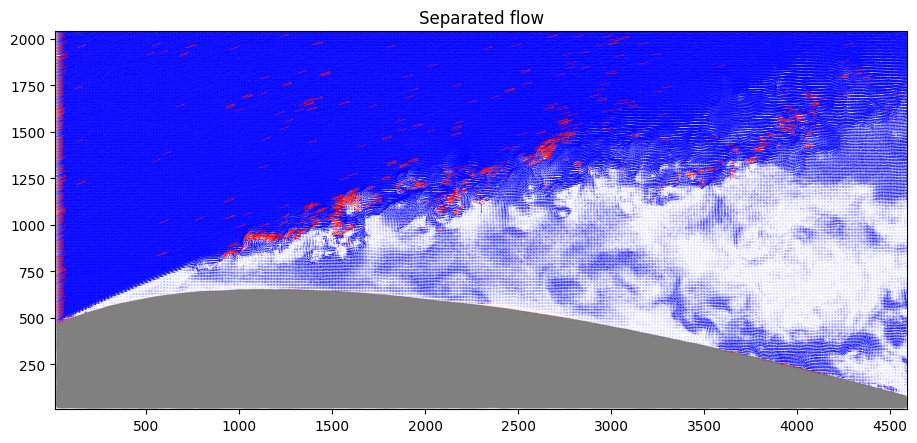

In [7]:


#@title Plot the results
# Create a figure.
fig, ax = plt.subplots(figsize=(11, 11))
ax.set_aspect(1)
vector_width = 0.0005
vector_scale = 1000

# Modify tick labels and ticks.
tick_step = 250
ax.set_xticks(range(0, int(x[0, -1]), 2 * tick_step))
ax.set_yticks(range(0, int(y[0, -1]), tick_step))

# Adjust the axis limits to the minimum and maximum range.
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())

# Show the quiver plot.
ax.quiver(x[_loc], y[_loc], u[_loc], v[_loc], color="b", width=vector_width, scale=vector_scale)
ax.quiver(x[loc], y[loc], u[loc], v[loc], color="r", width=vector_width, scale=vector_scale)
ax.set_title(f"Separated flow")

# Show the mask on the plot.
ax.imshow(~mask, cmap='gray', alpha=0.5, extent=[x.min(), x.max(), y.min(), y.max()])
plt.show()

